# Lab 1 – CS4085 Deep Learning

## Logistic Regression with a Neural Network Mindset

In this lab, you will build a logistic regression classifier to recognize cat and non-cat images using a neural-network mindset.

**Instructions:**
- Complete all exercise cells marked with `YOUR CODE STARTS HERE` and `YOUR CODE ENDS HERE`.
- Do not use loops (`for`/`while`) unless the exercise explicitly asks you to do so.
- Use `np.dot(X, Y)` for dot products where appropriate.
- Run the provided test cells after completing each exercise.

**Learning objectives:**
- Initialize model parameters.
- Compute the cost function and gradients.
- Apply gradient descent.
- Make predictions using learned parameters.
- Combine the components into a complete model.


## Table of Contents
- [1 - Packages](#1)
- [2 - Overview of the Problem set](#2)
    - [Exercise 1](#ex-1)
    - [Exercise 2](#ex-2)
- [3 - General Architecture of the learning algorithm](#3)
- [4 - Building the parts of our algorithm](#4)
    - [4.1 - Helper functions](#4-1)
        - [Exercise 3 - sigmoid](#ex-3)
    - [4.2 - Initializing parameters](#4-2)
        - [Exercise 4 - initialize_with_zeros](#ex-4)
    - [4.3 - Forward and Backward propagation](#4-3)
        - [Exercise 5 - propagate](#ex-5)
    - [4.4 - Optimization](#4-4)
        - [Exercise 6 - optimize](#ex-6)
        - [Exercise 7 - predict](#ex-7)
- [5 - Merge all functions into a model](#5)
    - [Exercise 8 - model](#ex-8)
- [6 - Further analysis (optional/ungraded exercise)](#6)
- [7 - Test with your own image (optional/ungraded exercise)](#7)

### How to run this lab

This notebook is **self-contained**: it does not need the Coursera files
`lr_utils.py` or `public_tests.py`, and it does not need an `images/` or
`datasets/` folder prepared in advance.

1. Open the notebook in **Google Colab** (`File > Upload notebook`) or in
   **Anaconda / JupyterLab** on your own computer.
2. Run the two setup cells in Section 1 once, from top to bottom.
3. The cat / non-cat dataset is downloaded automatically the first time you
   run it and cached in a `datasets/` folder next to the notebook. If you
   have no internet access, the notebook automatically switches to an
   offline stand-in dataset of the same shape so that every later cell
   still runs.
4. Complete each `YOUR CODE STARTS HERE` block and run the test cell below
   it. A test either prints `All tests passed.` or tells you what is wrong.

Only `numpy`, `matplotlib`, `h5py` and `pillow` are required; all four are
already installed in Colab and Anaconda.

<a name='1'></a>
## 1 - Packages ##

Run the cells below to import the packages and to load the helper code this
lab needs.
- [numpy](https://numpy.org/doc/stable/) is the fundamental package for scientific computing with Python.
- [h5py](http://www.h5py.org) is used to read the dataset, which is stored in an HDF5 file.
- [matplotlib](http://matplotlib.org) is a famous library to plot graphs in Python.
- [PIL](https://pillow.readthedocs.io/en/stable/) is used at the end to test your model on your own picture.

The next two cells replace the Coursera-only files `lr_utils.py` and
`public_tests.py`. Run them once and do not edit them.

In [38]:
### Lab 1 - version 2.0 (self-contained: no Coursera files needed)

import copy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

In [39]:
# numpy is for mathematical calculations
# matplotlib for plotting
# the dataset is on the server, gave the link to the data and then created a fetch function to retrieve the values

In [40]:
# =====================================================================
#  LAB SETUP - run this cell first, and do not edit it.
#
#  This lab is self-contained. The dataset loader and the automatic
#  checks used to come from the Coursera files `lr_utils.py` and
#  `public_tests.py`; they are defined here instead, so the notebook
#  runs in Google Colab, Anaconda / JupyterLab, or any plain Python
#  environment with no extra files to download.
#
#  Needs only: numpy, matplotlib, h5py, pillow  (all are preinstalled
#  in Colab and Anaconda). If h5py is missing, run in a cell:
#      !pip install h5py
# =====================================================================

import os
import urllib.request

import numpy as np

DATA_DIR = "datasets"
DATASET_SOURCE = None          # set by load_dataset(): "cats" or "stand-in"

_MIRRORS = [
    "https://raw.githubusercontent.com/dangnam739/deep-learning-coursera/master/"
    "Neural%20Networks%20and%20Deep%20Learning/Week%202%20-%20Neural%20Networks%20Basics/"
    "Exercise/datasets",
    "https://raw.githubusercontent.com/liqiang311/deeplearning.ai/master/"
    "1_Neural%20Networks%20and%20Deep%20Learning/week2/"
    "Logistic%20Regression%20as%20a%20Neural%20Network/datasets",
    "https://raw.githubusercontent.com/JudasDie/deeplearning.ai/master/"
    "Improving%20Deep%20Neural%20Networks/Week1/Regularization/datasets",
]


def _fetch(filename, timeout=60):
    """Return a local path to `filename`, downloading it once if needed."""
    os.makedirs(DATA_DIR, exist_ok=True)
    local = os.path.join(DATA_DIR, filename)
    if os.path.exists(local) and os.path.getsize(local) > 100000:
        return local
    last_error = None
    for base in _MIRRORS:
        try:
            with urllib.request.urlopen(base + "/" + filename, timeout=timeout) as response:
                data = response.read()
            if not data.startswith(b"\x89HDF"):
                raise ValueError("downloaded file is not an HDF5 file")
            with open(local, "wb") as handle:
                handle.write(data)
            return local
        except Exception as error:          # try the next mirror
            last_error = error
    raise RuntimeError("could not download %s (%s)" % (filename, last_error))


def _stand_in_dataset(m_train=209, m_test=50, num_px=64, seed=1):
    """Offline substitute with exactly the same shapes as the cat dataset.

    Used only when the notebook has no internet access, so the rest of the
    lab still runs. Class 1 images contain a coloured blob; class 0 images
    do not.
    """
    rng = np.random.default_rng(seed)
    rows, cols = np.mgrid[0:num_px, 0:num_px]

    def build(m):
        y = rng.integers(0, 2, size=m)
        x = rng.integers(55, 125, size=(m, num_px, num_px, 3)).astype(np.int16)
        x += rng.integers(-15, 16, size=(m, 1, 1, 3))           # per-image tint
        for i in range(m):
            if y[i] == 1:
                cy, cx = rng.integers(18, num_px - 18, size=2)
                radius = rng.integers(10, 17)
                blob = (rows - cy) ** 2 + (cols - cx) ** 2 < radius ** 2
                x[i][blob] += np.array([95, 45, -25], dtype=np.int16)
        x = np.clip(x, 0, 255).astype(np.uint8)
        return x, y.reshape(1, m)

    train_x, train_y = build(m_train)
    test_x, test_y = build(m_test)
    classes = np.array([b"non-cat", b"cat"])
    return train_x, train_y, test_x, test_y, classes


def load_dataset():
    """Load the cat / non-cat dataset (downloads it once into ./datasets)."""
    global DATASET_SOURCE
    import h5py
    try:
        train_path = _fetch("train_catvnoncat.h5")
        test_path = _fetch("test_catvnoncat.h5")
        with h5py.File(train_path, "r") as f:
            train_set_x_orig = np.array(f["train_set_x"][:])
            train_set_y_orig = np.array(f["train_set_y"][:])
            classes = np.array(f["list_classes"][:])
        with h5py.File(test_path, "r") as f:
            test_set_x_orig = np.array(f["test_set_x"][:])
            test_set_y_orig = np.array(f["test_set_y"][:])
        train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
        test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
        DATASET_SOURCE = "cats"
        print("Cat / non-cat dataset ready (files kept in ./%s)." % DATA_DIR)
        return (train_set_x_orig, train_set_y_orig,
                test_set_x_orig, test_set_y_orig, classes)
    except Exception as error:
        DATASET_SOURCE = "stand-in"
        print("Could not obtain the cat / non-cat files: %s" % error)
        print("No internet access? Using an offline stand-in dataset with the")
        print("same shapes so the rest of the lab still runs normally.")
        return _stand_in_dataset()


# --- check for Exercise 2 (replaces the hard-coded Coursera assertions) ------

_FIRST_10_TRAIN = [196, 192, 190, 193, 186, 182, 188, 179, 174, 213]
_FIRST_10_TEST = [115, 110, 111, 137, 129, 129, 155, 146, 145, 159]


def check_flatten(train_flat, test_flat, train_orig, test_orig):
    """Verify that the images were flattened column-wise."""
    for flat, orig, name in ((train_flat, train_orig, "train"),
                             (test_flat, test_orig, "test")):
        wanted = (orig.shape[1] * orig.shape[2] * orig.shape[3], orig.shape[0])
        assert flat.shape == wanted, (
            "%s_set_x_flatten should have shape %s but has %s. "
            "Use (X.shape[0], -1).T" % (name, wanted, flat.shape))
        assert np.array_equal(flat[:, 1], orig[1].reshape(-1)), (
            "Every column of %s_set_x_flatten must be one flattened image. "
            "Use (X.shape[0], -1).T" % name)
    if DATASET_SOURCE == "cats":
        assert np.all(train_flat[0:10, 1] == _FIRST_10_TRAIN), "Wrong solution. Use (X.shape[0], -1).T."
        assert np.all(test_flat[0:10, 1] == _FIRST_10_TEST), "Wrong solution. Use (X.shape[0], -1).T."
    print("\033[92mReshaping is correct.\033[0m")


print("Lab setup loaded.")

Lab setup loaded.


In [41]:
# =====================================================================
#  AUTOMATIC CHECKS - run this cell, and do not edit it.
#  These replace the Coursera file `public_tests.py`.
#  Each test prints "All tests passed." or raises an error telling you
#  what is wrong with your function.
# =====================================================================

import copy as _copy

_OK = "\033[92mAll tests passed.\033[0m"


def sigmoid_test(target):
    assert np.allclose(target(np.array([0, 2])), [0.5, 0.88079708]), \
        "sigmoid([0, 2]) should be [0.5, 0.88079708]"
    assert np.allclose(target(0), 0.5), "sigmoid(0) should be 0.5"
    z = np.array([[-1.0, 0.0], [2.0, 3.5]])
    expected = np.array([[0.26894142, 0.5], [0.88079708, 0.97068777]])
    out = target(z)
    assert isinstance(out, np.ndarray) and out.shape == z.shape, \
        "sigmoid must keep the shape of its input - use np.exp, not math.exp"
    assert np.allclose(out, expected), "sigmoid is wrong on a 2-D array"
    assert np.allclose(target(np.array([-500.0, 500.0])), [0.0, 1.0]), \
        "sigmoid should saturate to 0 and 1 for large |z|"
    print(_OK)


def initialize_with_zeros_test_1(target):
    w, b = target(3)
    assert isinstance(w, np.ndarray), "w must be a numpy array"
    assert w.shape == (3, 1), "w should have shape (3, 1) but has %s" % (w.shape,)
    assert np.allclose(w, 0), "w must contain only zeros"
    assert type(b) == float, "b must be a python float (write 0.0, not np.zeros(1))"
    assert b == 0.0, "b must be 0.0"
    print(_OK)


def initialize_with_zeros_test_2(target):
    w, b = target(4)
    assert w.shape == (4, 1), "w should have shape (4, 1) but has %s" % (w.shape,)
    assert np.allclose(w, 0) and b == 0.0, "w must be all zeros and b must be 0.0"
    assert w.dtype == float, "w should hold floats"
    w2, _ = target(1)
    assert w2.shape == (1, 1), "initialize_with_zeros(1) should give w of shape (1, 1)"
    print(_OK)


def propagate_test(target):
    w = np.array([[1.0], [2.0]])
    b = 1.5
    X = np.array([[1.0, -2.0, -1.0], [3.0, 0.5, -3.2]])
    Y = np.array([[1, 1, 0]])
    grads, cost = target(w, b, X, Y)
    assert isinstance(grads, dict) and "dw" in grads and "db" in grads, \
        "propagate must return a dict with keys 'dw' and 'db'"
    assert grads["dw"].shape == w.shape, "dw must have the same shape as w"
    assert np.allclose(grads["dw"], [[0.25071532], [-0.06604096]]), "dw is wrong"
    assert np.allclose(grads["db"], -0.12500405), "db is wrong"
    assert np.allclose(cost, 0.15900538), "cost is wrong"
    assert np.ndim(cost) == 0, "cost must be a scalar"

    w = np.array([[0.3], [-0.5], [0.8]])
    b = -0.2
    X = np.array([[1.0, 2.0, -1.0, 0.0], [0.5, -1.0, 2.0, 1.0], [-1.0, 0.0, 1.0, 2.0]])
    Y = np.array([[1, 0, 1, 0]])
    grads, cost = target(w, b, X, Y)
    assert np.allclose(grads["dw"], [[0.3422429], [-0.42423328], [0.3687066]]), \
        "dw is wrong on the second test (check the 1/m factor and X(A-Y).T)"
    assert np.allclose(grads["db"], 0.00814901), "db is wrong on the second test"
    assert np.allclose(cost, 1.21561255), "cost is wrong on the second test"
    print(_OK)


def optimize_test(target):
    w = np.array([[1.0], [2.0]])
    b = 1.5
    X = np.array([[1.0, -2.0, -1.0], [3.0, 0.5, -3.2]])
    Y = np.array([[1, 1, 0]])
    w_backup = w.copy()

    params, grads, costs = target(w, b, X, Y, num_iterations=101,
                                  learning_rate=0.009, print_cost=False)

    assert np.allclose(w, w_backup), \
        "optimize must not modify the w it was given (that is what copy.deepcopy is for)"
    assert np.allclose(params["w"], [[0.80795802], [2.05125464]]), \
        "w was not updated correctly - check the update rule w = w - learning_rate * dw"
    assert np.allclose(params["b"], 1.59566877), "b was not updated correctly"
    assert np.allclose(grads["dw"], [[0.178049], [-0.04827102]]), "dw is wrong"
    assert np.allclose(grads["db"], -0.08860601), "db is wrong"
    assert len(costs) == 2, "costs should hold one value every 100 iterations"
    assert np.allclose(costs, [0.15900538, 0.10541138]), "the recorded costs are wrong"
    print(_OK)


def predict_test(target):
    w = np.array([[0.1124579], [0.23106775]])
    b = -0.3
    X = np.array([[1.0, -1.1, -3.2], [1.2, 2.0, 0.1]])
    pred = target(w, b, X)
    assert isinstance(pred, np.ndarray), "predict must return a numpy array"
    assert pred.shape == (1, X.shape[1]), \
        "predictions should have shape (1, m) but have %s" % (pred.shape,)
    assert np.all(np.isin(pred, [0, 1])), "predictions must be only 0 or 1"
    assert np.allclose(pred, [[1.0, 1.0, 0.0]]), "the predictions are wrong"

    zeros = target(np.zeros((2, 1)), 0.0, X)
    assert np.allclose(zeros, [[0.0, 0.0, 0.0]]), \
        "when the activation is exactly 0.5 the prediction must be 0 (use a > 0.5)"
    print(_OK)


def model_test(target):
    rng = np.random.default_rng(0)
    X_train = rng.normal(size=(4, 20))
    Y_train = (np.sum(X_train, axis=0, keepdims=True) > 0).astype(float)
    X_test = rng.normal(size=(4, 8))
    Y_test = (np.sum(X_test, axis=0, keepdims=True) > 0).astype(float)

    d = target(X_train, Y_train, X_test, Y_test,
               num_iterations=250, learning_rate=0.1, print_cost=False)

    for key in ("costs", "Y_prediction_test", "Y_prediction_train",
                "w", "b", "learning_rate", "num_iterations"):
        assert key in d, "the returned dictionary is missing the key '%s'" % key
    assert d["w"].shape == (4, 1), "w should have shape (4, 1) but has %s" % (d["w"].shape,)
    assert d["Y_prediction_train"].shape == Y_train.shape, \
        "Y_prediction_train has the wrong shape"
    assert d["Y_prediction_test"].shape == Y_test.shape, \
        "Y_prediction_test has the wrong shape"
    assert len(d["costs"]) == 3, "costs should hold one value every 100 iterations"
    assert np.allclose(d["costs"][0], 0.69314718), \
        "the first cost should be log(2) - did you initialise w and b with zeros?"
    assert d["costs"][-1] < d["costs"][0], "the cost should go down during training"
    assert np.allclose(d["w"], [[1.59854283], [1.61867667], [1.69085271], [1.12722706]]), \
        "the learned w is wrong - check the order of the steps inside model()"
    assert np.allclose(d["b"], 0.02069309), "the learned b is wrong"
    train_acc = 100 - np.mean(np.abs(d["Y_prediction_train"] - Y_train)) * 100
    test_acc = 100 - np.mean(np.abs(d["Y_prediction_test"] - Y_test)) * 100
    assert train_acc == 100.0 and test_acc == 100.0, \
        "the model should separate this easy toy dataset perfectly"
    print(_OK)


print("Checks loaded: sigmoid_test, initialize_with_zeros_test_1/2, "
      "propagate_test, optimize_test, predict_test, model_test")

Checks loaded: sigmoid_test, initialize_with_zeros_test_1/2, propagate_test, optimize_test, predict_test, model_test


<a name='2'></a>
## 2 - Overview of the Problem set ##

**Problem Statement**: You are given a dataset ("data.h5") containing:
    - a training set of m_train images labeled as cat (y=1) or non-cat (y=0)
    - a test set of m_test images labeled as cat or non-cat
    - each image is of shape (num_px, num_px, 3) where 3 is for the 3 channels (RGB). Thus, each image is square (height = num_px) and (width = num_px).

You will build a simple image-recognition algorithm that can correctly classify pictures as cat or non-cat.

Let's get more familiar with the dataset. Load the data by running the following code.

In [42]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

Cat / non-cat dataset ready (files kept in ./datasets).


We added "_orig" at the end of image datasets (train and test) because we are going to preprocess them. After preprocessing, we will end up with train_set_x and test_set_x (the labels train_set_y and test_set_y don't need any preprocessing).

Each line of your train_set_x_orig and test_set_x_orig is an array representing an image. You can visualize an example by running the following code. Feel free also to change the `index` value and re-run to see other images.

y = [1], it's a 'cat' picture.


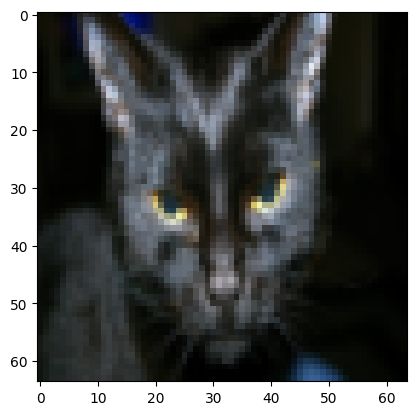

In [43]:
# Example of a picture
# printing the label in the last line
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

Many software bugs in deep learning come from having matrix/vector dimensions that don't fit. If you can keep your matrix/vector dimensions straight you will go a long way toward eliminating many bugs.

<a name='ex-1'></a>
### Exercise 1
Find the values for:
    - m_train (number of training examples)
    - m_test (number of test examples)
    - num_px (= height = width of a training image)
Remember that `train_set_x_orig` is a numpy-array of shape (m_train, num_px, num_px, 3). For instance, you can access `m_train` by writing `train_set_x_orig.shape[0]`.

In [44]:
#(≈ 3 lines of code)
# m_train =
# m_test =
# num_px =
# YOUR CODE STARTS HERE
# TODO: Write your solution here.
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
# YOUR CODE ENDS HERE

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


**Check your work:** Run the cell above and verify that the reported dataset dimensions are consistent with the shapes of the loaded arrays.


For convenience, you should now reshape images of shape (num_px, num_px, 3) in a numpy-array of shape (num_px $*$ num_px $*$ 3, 1). After this, our training (and test) dataset is a numpy-array where each column represents a flattened image. There should be m_train (respectively m_test) columns.

<a name='ex-2'></a>
### Exercise 2
Reshape the training and test data sets so that images of size (num_px, num_px, 3) are flattened into single vectors of shape (num\_px $*$ num\_px $*$ 3, 1).

A trick when you want to flatten a matrix X of shape (a,b,c,d) to a matrix X_flatten of shape (b$*$c$*$d, a) is to use:
```python
X_flatten = X.reshape(X.shape[0], -1).T      # X.T is the transpose of X
```

In [45]:
# VECTORIZATION
# Reshape the training and test examples
#(≈ 2 lines of code)
# train_set_x_flatten = ...
# test_set_x_flatten = ...
# YOUR CODE STARTS HERE
# TODO: Write your solution here.
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
# YOUR CODE ENDS HERE

# Check that each image has become one column
check_flatten(train_set_x_flatten, test_set_x_flatten,
              train_set_x_orig, test_set_x_orig)

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Reshaping is correct.
train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


**Check your work:** Run the cell above and verify that each flattened image is represented as one column and that the number of examples is unchanged.


To represent color images, the red, green and blue channels (RGB) must be specified for each pixel, and so the pixel value is actually a vector of three numbers ranging from 0 to 255.

One common preprocessing step in machine learning is to center and standardize your dataset, meaning that you substract the mean of the whole numpy array from each example, and then divide each example by the standard deviation of the whole numpy array. But for picture datasets, it is simpler and more convenient and works almost as well to just divide every row of the dataset by 255 (the maximum value of a pixel channel).

<!-- During the training of your model, you're going to multiply weights and add biases to some initial inputs in order to observe neuron activations. Then you backpropogate with the gradients to train the model. But, it is extremely important for each feature to have a similar range such that our gradients don't explode. You will see that more in detail later in the lectures. !-->

Let's standardize our dataset.

In [46]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

<font color='blue'>
    
    
**What you need to remember:**

Common steps for pre-processing a new dataset are:
- Figure out the dimensions and shapes of the problem (m_train, m_test, num_px, ...)
- Reshape the datasets such that each example is now a vector of size (num_px \* num_px \* 3, 1)
- "Standardize" the data

<a name='3'></a>
## 3 - General Architecture of the learning algorithm ##

It's time to design a simple algorithm to distinguish cat images from non-cat images.

You will build a Logistic Regression, using a Neural Network mindset. The following figure explains why **Logistic Regression is actually a very simple Neural Network!**

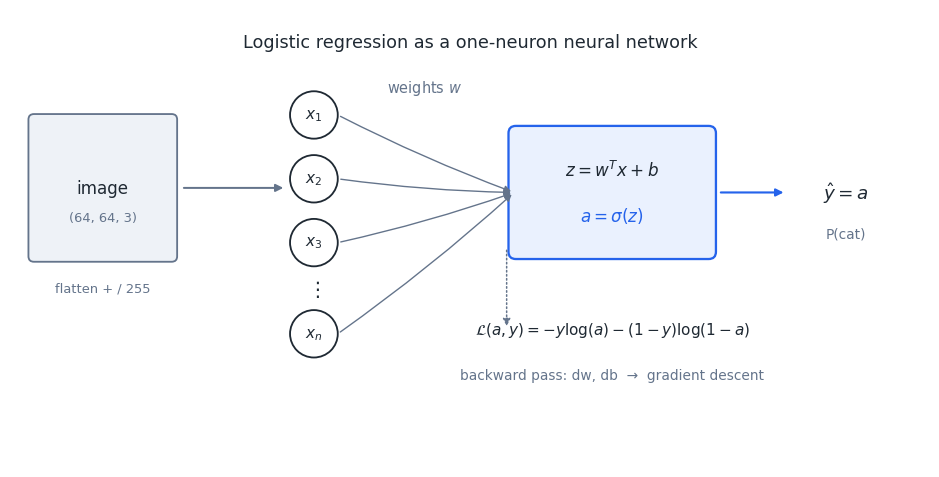

**Mathematical expression of the algorithm**:

For one example $x^{(i)}$:
$$z^{(i)} = w^T x^{(i)} + b \tag{1}$$
$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})\tag{2}$$
$$ \mathcal{L}(a^{(i)}, y^{(i)}) =  - y^{(i)}  \log(a^{(i)}) - (1-y^{(i)} )  \log(1-a^{(i)})\tag{3}$$

The cost is then computed by summing over all training examples:
$$ J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})\tag{6}$$

**Key steps**:
In this exercise, you will carry out the following steps:
    - Initialize the parameters of the model
    - Learn the parameters for the model by minimizing the cost
    - Use the learned parameters to make predictions (on the test set)
    - Analyse the results and conclude

<a name='4'></a>
## 4 - Building the parts of our algorithm ##

The main steps for building a Neural Network are:
1. Define the model structure (such as number of input features)
2. Initialize the model's parameters
3. Loop:
    - Calculate current loss (forward propagation)
    - Calculate current gradient (backward propagation)
    - Update parameters (gradient descent)

You often build 1-3 separately and integrate them into one function we call `model()`.

<a name='4-1'></a>
### 4.1 - Helper functions

<a name='ex-3'></a>
### Exercise 3 - sigmoid
Using your code from "Python Basics", implement `sigmoid()`. As you've seen in the figure above, you need to compute $sigmoid(z) = \frac{1}{1 + e^{-z}}$ for $z = w^T x + b$ to make predictions. Use np.exp().

In [47]:
# GRADED FUNCTION: sigmoid

def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    # YOUR CODE STARTS HERE
    # TODO: Write your solution here.
    s = 1 / (1 + np.exp(-z))
    # YOUR CODE ENDS HERE

    return s

In [48]:
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid_test(sigmoid)

sigmoid([0, 2]) = [0.5        0.88079708]
All tests passed.


In [49]:
x = np.array([0.5, 0, 2.0])
output = sigmoid(x)
print(output)

[0.62245933 0.5        0.88079708]


<a name='4-2'></a>
### 4.2 - Initializing parameters

<a name='ex-4'></a>
### Exercise 4 - initialize_with_zeros
Implement parameter initialization in the cell below. You have to initialize w as a vector of zeros. If you don't know what numpy function to use, look up np.zeros() in the Numpy library's documentation.

In [50]:
import numpy as np
# GRADED FUNCTION: initialize_with_zeros

def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (dim, 1)
    for w and initializes b to 0.
    """

    # YOUR CODE STARTS HERE
    # TODO: Write your solution here.
    w = np.zeros((dim, 1))
    b = 0.0
    # YOUR CODE ENDS HERE

    return w, b

In [51]:
dim = 2
w, b = initialize_with_zeros(dim)

assert type(b) == float
print ("w = " + str(w))
print ("b = " + str(b))

initialize_with_zeros_test_1(initialize_with_zeros)
initialize_with_zeros_test_2(initialize_with_zeros)


w = [[0.]
 [0.]]
b = 0.0
All tests passed.
All tests passed.


<a name='4-3'></a>
### 4.3 - Forward and Backward propagation

Now that your parameters are initialized, you can do the "forward" and "backward" propagation steps for learning the parameters.

<a name='ex-5'></a>
### Exercise 5 - propagate
Implement a function `propagate()` that computes the cost function and its gradient.

**Hints**:

Forward Propagation:
- You get X
- You compute $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$
- You calculate the cost function: $J = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)}))$

Here are the two formulas you will be using:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T\tag{7}$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})\tag{8}$$

In [52]:
# GRADED FUNCTION: propagate

def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient.
    """

    m = X.shape[1]

    # FORWARD PROPAGATION
    # YOUR CODE STARTS HERE
    # TODO: Write your solution here.
    z = np.dot(w.T, X) + b
    A = sigmoid(z)
    cost = -1 / m * (np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A)))
    # YOUR CODE ENDS HERE

    # BACKWARD PROPAGATION
    # YOUR CODE STARTS HERE
    # TODO: Write your solution here.
    dw = 1 / m * (np.dot(X, (A - Y).T))
    db = 1 / m * (np.sum(A - Y))
    # YOUR CODE ENDS HERE

    cost = np.squeeze(np.array(cost))

    grads = {
        "dw": dw,
        "db": db
    }

    return grads, cost

In [53]:
w =  np.array([[1.], [2]])
b = 1.5

# X is using 3 examples, with 2 features each
# Each example is stacked column-wise
X = np.array([[1., -2., -1.], [3., 0.5, -3.2]])
Y = np.array([[1, 1, 0]])
grads, cost = propagate(w, b, X, Y)

assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == (2, 1)
assert type(grads["db"]) == np.float64


print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

propagate_test(propagate)

dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.1250040450043965
cost = 0.15900537707692405
All tests passed.


**Check your work:** Run the provided test cell to verify your implementation of `propagate()`.


<a name='4-4'></a>
### 4.4 - Optimization
- You have initialized your parameters.
- You are also able to compute a cost function and its gradient.
- Now, you want to update the parameters using gradient descent.

<a name='ex-6'></a>
### Exercise 6 - optimize
Write down the optimization function. The goal is to learn $w$ and $b$ by minimizing the cost function $J$. For a parameter $\theta$, the update rule is $ \theta = \theta - \alpha \text{ } d\theta$, where $\alpha$ is the learning rate.

In [54]:
# GRADED FUNCTION: optimize

def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    """
    This function optimizes w and b by running a gradient descent algorithm
    """

    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    costs = []

    for i in range(num_iterations):

        # Cost and gradient calculation
        # YOUR CODE STARTS HERE
        # TODO: Write your solution here.
        grads, cost = propagate(w, b, X, Y)
        # YOUR CODE ENDS HERE

        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # Update rule
        # YOUR CODE STARTS HERE
        # TODO: Write your solution here.
        w = w - (learning_rate * dw)
        b = b - (learning_rate * db)
        # YOUR CODE ENDS HERE

        # Record the costs
        if i % 100 == 0:
            costs.append(cost)

            # Print the cost every 100 iterations
            if print_cost:
                print("Cost after iteration %i: %f" % (i, cost))

    params = {
        "w": w,
        "b": b
    }

    grads = {
        "dw": dw,
        "db": db
    }

    return params, grads, costs

In [55]:
params, grads, costs = optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print("Costs = " + str(costs))

optimize_test(optimize)

w = [[0.80956046]
 [2.0508202 ]]
b = 1.5948713189708588
dw = [[ 0.17860505]
 [-0.04840656]]
db = -0.08888460336847771
Costs = [array(0.15900538)]
All tests passed.


<a name='ex-7'></a>
### Exercise 7 - predict
The previous function will output the learned w and b. We are able to use w and b to predict the labels for a dataset X. Implement the `predict()` function. There are two steps to computing predictions:

1. Calculate $\hat{Y} = A = \sigma(w^T X + b)$

2. Convert the entries of a into 0 (if activation <= 0.5) or 1 (if activation > 0.5), stores the predictions in a vector `Y_prediction`. If you wish, you can use an `if`/`else` statement in a `for` loop (though there is also a way to vectorize this).

In [65]:
# GRADED FUNCTION: predict

def predict(w, b, X):
    """
    Predict whether the label is 0 or 1 using learned
    logistic regression parameters (w, b)
    """

    m = X.shape[1]
    Y_prediction = np.zeros((1, m))

    w = w.reshape(X.shape[0], 1)

    # YOUR CODE STARTS HERE
    # TODO: Write your solution here.
    z = np.dot(w.T, X) + b
    A = sigmoid(z)
    # YOUR CODE ENDS HERE

    for i in range(A.shape[1]):

        # YOUR CODE STARTS HERE
        # TODO: Write your solution here.
        if A[0, i] <= 0.5:
            Y_prediction[0, i] = 0
        else:
            Y_prediction[0, i] = 1
        # YOUR CODE ENDS HERE

    return Y_prediction

In [66]:
w = np.array([[0.1124579], [0.23106775]])
b = -0.3
X = np.array([[1., -1.1, -3.2],[1.2, 2., 0.1]])
print ("predictions = " + str(predict(w, b, X)))

predict_test(predict)

predictions = [[1. 1. 0.]]
All tests passed.


<font color='blue'>
    
**What to remember:**
    
You've implemented several functions that:
- Initialize (w,b)
- Optimize the loss iteratively to learn parameters (w,b):
    - Computing the cost and its gradient
    - Updating the parameters using gradient descent
- Use the learned (w,b) to predict the labels for a given set of examples

<a name='5'></a>
## 5 - Merge all functions into a model ##

You will now see how the overall model is structured by putting together all the building blocks (functions implemented in the previous parts) together, in the right order.

<a name='ex-8'></a>
### Exercise 8 - model
Implement the model function. Use the following notation:
    - Y_prediction_test for your predictions on the test set
    - Y_prediction_train for your predictions on the train set
    - parameters, grads, costs for the outputs of optimize()

In [58]:
# GRADED FUNCTION: model

def model(X_train, Y_train, X_test, Y_test,
          num_iterations=2000,
          learning_rate=0.5,
          print_cost=False):

    # YOUR CODE STARTS HERE
    # TODO: Write your solution here.
    w, b = initialize_with_zeros(X_train.shape[0])
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)

    w = parameters["w"]
    b = parameters["b"]

    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    # YOUR CODE ENDS HERE

    # Print train/test Errors
    if print_cost:
        print("train accuracy: {} %".format(
            100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
        ))
        print("test accuracy: {} %".format(
            100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
        ))

    d = {
        "costs": costs,
        "Y_prediction_test": Y_prediction_test,
        "Y_prediction_train": Y_prediction_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations
    }

    return d

In [59]:
model_test(model)

All tests passed.


If you pass all the tests, run the following cell to train your model.

In [67]:
logistic_regression_model = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


### Analysis Questions

After training the model, answer the following:
1. What are the training and test accuracies?
2. Is there evidence of overfitting? Explain briefly.
3. Why might logistic regression have limitations on this image-classification task?




1. Training set accuracy is 99.04% and test set accuracy is 70.00%
2. Yes, becuase the traingin set gave use very high results, but the testing results were not too string
3. Overfitting would be a limitation, as seen above and maybe logistic regression is too simple for complex images and finding relationships between them.



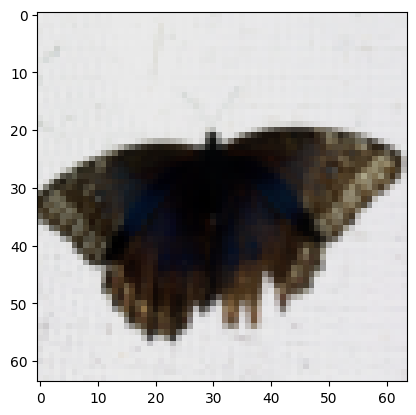

y = 0, you predicted that it is a "cat" picture.


In [68]:
# Example of a picture that was wrongly classified.
index = 13   # Other options you could try: 6, 10, 11, 13

plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
plt.show()
print ("y = " + str(test_set_y[0, index]) + ", you predicted that it is a \"" +
       classes[int(logistic_regression_model['Y_prediction_test'][0, index])].decode("utf-8") +
       "\" picture.")

Let's also plot the cost function and the gradients.

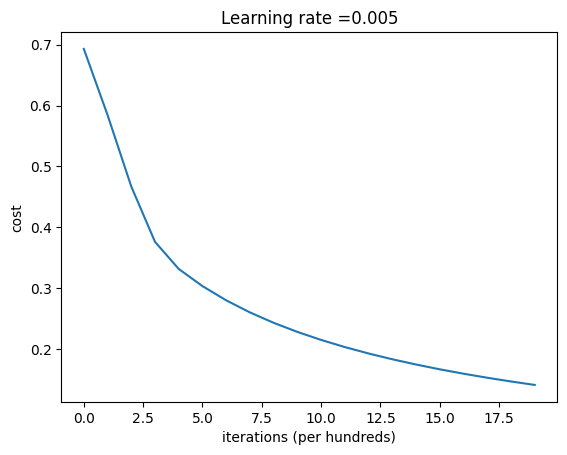

In [62]:
# Plot learning curve (with costs)
costs = np.squeeze(logistic_regression_model['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(logistic_regression_model["learning_rate"]))
plt.show()

### Learning-Curve Analysis

Inspect the cost curve and answer:
1. Does the cost generally decrease during training?
2. What does the trend tell you about gradient descent?
3. What might happen to training and test performance if you greatly increase the number of iterations?


1. Yes teh cost (error) gradually decreases during the training
2. The gradient descent is doing its work and reducing the error with every iteration.
3. The training performance might imporve, but the test performamight stay the same or decrease due to overfitting.

<a name='6'></a>
## 6 - Further analysis (optional/ungraded exercise) ##

Congratulations on building your first image classification model. Let's analyze it further, and examine possible choices for the learning rate $\alpha$.

#### Choice of learning rate ####

**Reminder**:
In order for Gradient Descent to work you must choose the learning rate wisely. The learning rate $\alpha$  determines how rapidly we update the parameters. If the learning rate is too large we may "overshoot" the optimal value. Similarly, if it is too small we will need too many iterations to converge to the best values. That's why it is crucial to use a well-tuned learning rate.

Let's compare the learning curve of our model with several choices of learning rates. Run the cell below. This should take about 1 minute. Feel free also to try different values than the three we have initialized the `learning_rates` variable to contain, and see what happens.

Training a model with learning rate: 0.01

-------------------------------------------------------

Training a model with learning rate: 0.001

-------------------------------------------------------

Training a model with learning rate: 0.0001

-------------------------------------------------------



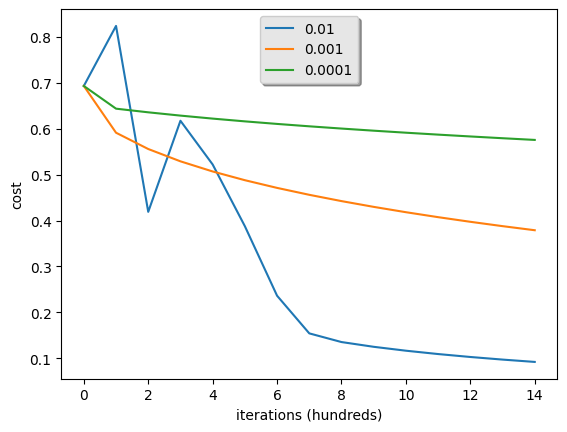

In [63]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print ("Training a model with learning rate: " + str(lr))
    models[str(lr)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=1500, learning_rate=lr, print_cost=False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["costs"]), label=str(models[str(lr)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

### Learning-Rate Analysis

Compare the learning curves produced by the different learning rates and answer:
1. Which learning rate converges fastest?
2. Which learning rate appears most stable?
3. What happens when the learning rate is too large or too small?
4. Which learning rate would you choose for this experiment, and why?


1. 0.001 converges the fastest because it decreases at a stable rate and has a larger cost drop.
2. 0.0001 appears as the most stable learning rate.
3. When the learning rate is too large, it may skip over the local minima. If it is too small, it takes too long to converge.
4. 0.0001 as it converges at a stable rate, so it wont skip over the local minima and the cost decrease is still good.

<a name='7'></a>
## 7 - Test with your own image (optional/ungraded exercise) ##

Congratulations on finishing this assignment. You can now try your own image and see what your model predicts.

1. Put an image file (`.jpg` or `.png`) in the same folder as this notebook.
   - In **Google Colab**: click the folder icon in the left sidebar, then the upload button, and drop your file there.
   - In **Jupyter / Anaconda**: simply copy the file next to the notebook.
2. Change `my_image` below to the name of your file.
3. Run the cell and check whether the algorithm is right (1 = cat, 0 = non-cat).

If you leave the file name as it is and no such file exists, the cell just prints a short reminder instead of raising an error.

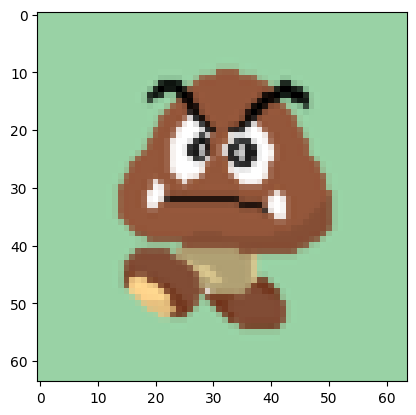

y = 0.0, your algorithm predicts a "non-cat" picture.


In [69]:
import os

# change this to the name of your own image file
my_image = "my_image.png"

if not os.path.exists(my_image):
    print("No file named '%s' next to this notebook, so there is nothing to "
          "classify." % my_image)
    print("Upload an image, put its file name in my_image above, and run this "
          "cell again.")
else:
    # We preprocess the image to fit your algorithm.
    image = np.array(Image.open(my_image).convert("RGB").resize((num_px, num_px)))
    plt.imshow(image)
    plt.show()

    image = image / 255.
    image = image.reshape((1, num_px * num_px * 3)).T
    my_predicted_image = predict(logistic_regression_model["w"],
                                 logistic_regression_model["b"], image)

    print("y = " + str(np.squeeze(my_predicted_image)) +
          ", your algorithm predicts a \"" +
          classes[int(np.squeeze(my_predicted_image))].decode("utf-8") +
          "\" picture.")

<font color='blue'>
    
**What to remember from this assignment:**
1. Preprocessing the dataset is important.
2. You implemented each function separately: initialize(), propagate(), optimize(). Then you built a model().
3. Tuning the learning rate (which is an example of a "hyperparameter") can make a big difference to the algorithm. You will see more examples of this later in this course!

Finally, if you'd like, we invite you to try different things on this Notebook. Things you can play with include:
    - Play with the learning rate and the number of iterations
    - Try different initialization methods and compare the results
    - Test other preprocessings (center the data, or divide each row by its standard deviation)

Bibliography:
- http://www.wildml.com/2015/09/implementing-a-neural-network-from-scratch/
- https://stats.stackexchange.com/questions/211436/why-do-we-normalize-images-by-subtracting-the-datasets-image-mean-and-not-the-c